In [2]:
print('SHAPES')
for i,j in zip(all_distances, all_alerts):
    print(f'dist:{i.shape}, alert:{j.shape}')

SHAPES
dist:(1006, 1001), alert:(906, 901)
dist:(1004, 999), alert:(905, 900)
dist:(1003, 1002), alert:(906, 905)
dist:(1004, 999), alert:(905, 899)
dist:(1004, 998), alert:(905, 899)
dist:(1005, 999), alert:(905, 900)
dist:(1005, 1000), alert:(906, 901)
dist:(1006, 999), alert:(905, 900)


# 2. WITH RESAMPLING

In [179]:
from pathlib import Path
import os
import numpy as np
import rasterio
from rasterio.warp import reproject, Resampling

def extract_names():
    '''extract names for all the specific geographic areas that we have'''
    items = set()
    for id in os.scandir(Path('data/makeathon-challenge/labels/train/glads2')):
        items.add(id.name[7:16])
    return tuple(items)
##

CLUSTER_A = ['18NWG_6_6', '18NWH_1_4', '18NWJ_8_9', '18NWM_9_4', '18NXH_6_8', '18NXJ_7_6', '18NYH_9_9', '19NBD_4_4']
CLUSTER_B = ['47QMB_0_8', '47QQV_2_4', '48QVE_3_0', '48QWD_2_2']
CLUSTER_C = ['48PUT_0_8','48PWV_7_8', '48PXC_7_7', '48PYB_3_6']

'''
VALIDATION_IDS = [
    CLUSTER_A.pop(),
    CLUSTER_B.pop(),
    CLUSTER_C.pop()
]

TRAINING_IDS = CLUSTER_A + CLUSTER_B + CLUSTER_C
'''
all_ids = extract_names()
TRAINING_IDS, VALIDATION_IDS = all_ids[:-2], all_ids[-2:]

def handcraft_cosine(tens1, tens2):

    assert(tens1.shape == tens2.shape)
    dot_prod = np.sum(tens1*tens2, axis=0)

    norm_tens1 = np.linalg.norm(tens1, axis=0)
    norm_tens2 = np.linalg.norm(tens2, axis=0)

    cosine_sim = dot_prod / (norm_tens1 * norm_tens2 + 1e-8)
    return 1 - cosine_sim
##

PATH_TO_EMBEDDINGS = Path('data/makeathon-challenge/aef-embeddings/train')
YEARS = range(2020, 2026)

PATH_TO_ALERT_LEVEL = Path('data/makeathon-challenge/labels/train/glads2')

def normalize(n):
    '''Normalize an array so that its values span in [a,b]. Default is squeezing in [0,1]'''
    min, max = np.min(n), np.max(n)

    if max!=min:
        n = (n - min) / (max - min) # normalize in [0,1]
    else:
        print('encountered similar value while computing max and min of vector')
    return n
##

def prepare_for_logistic(
        ids,
):
    all_distances = []
    all_alerts = []
    # DESIRED_SHAPE = (905,899)
    for id in ids:

        with rasterio.open(PATH_TO_ALERT_LEVEL/f'glads2_{id}_alert.tif') as src:
            #dest = np.zeros(shape=DESIRED_SHAPE)
            glads2_alert = src.read(1)
            #glads2_alert = glads2_alert[:DESIRED_SHAPE[0], :DESIRED_SHAPE[1]]
            glad2_transform = src.transform
            glad2_crs = src.crs
            glad2_shape = glads2_alert.shape
        # glads2_alert -> ground truth

        aef_embeddings = []   # evolution of the embeddings
        for year in YEARS:   
            with rasterio.open(PATH_TO_EMBEDDINGS / f'{id}_{year}.tiff') as src:
                embedding_array = []
                for i in range(64):
                    destination_embedding = np.zeros(shape=glads2_alert.shape)
                    reproject(
                        source = src.read(i+1),
                        destination = destination_embedding,
                        src_transform=src.transform,
                        src_crs=src.crs,
                        dst_transform=glad2_transform,
                        dst_crs=glad2_crs,
                        resampling=Resampling.nearest
                    )
                    embedding_array.append(destination_embedding)
                ##
            ##
            aef_embeddings.append(np.stack(embedding_array))
        aef_embeddings = np.stack(aef_embeddings)

        cosine_distances = []
        for i in range(len(aef_embeddings)-1):
            tens1 = aef_embeddings[i]
            tens2 = aef_embeddings[i+1]
            cos_dist = handcraft_cosine(tens1, tens2)
            mask = np.isfinite(cos_dist)
            cosine_distances.append(np.where(mask, cos_dist, 0))
        ##
        cosine_distances = np.max(np.stack(cosine_distances), axis=0) # variations

        all_distances.append(normalize(cosine_distances))
        all_alerts.append(normalize(glads2_alert))
    

    return all_distances, all_alerts

    '''return (
        np.concatenate([i.flatten() for i in all_distances]), 
        np.concatenate([i.flatten() for i in all_alerts])
    )'''
##

all_distances, all_alerts = prepare_for_logistic(TRAINING_IDS)

'''all_distances = []
all_alerts = []
# DESIRED_SHAPE = (905,899)
for id in TRAINING_IDS:

    with rasterio.open(PATH_TO_ALERT_LEVEL/f'glads2_{id}_alert.tif') as src:
        #dest = np.zeros(shape=DESIRED_SHAPE)
        glads2_alert = src.read(1)
        #glads2_alert = glads2_alert[:DESIRED_SHAPE[0], :DESIRED_SHAPE[1]]
        glad2_transform = src.transform
        glad2_crs = src.crs
        glad2_shape = glads2_alert.shape
    # glads2_alert -> ground truth

    aef_embeddings = []   # evolution of the embeddings
    for year in YEARS:   
        with rasterio.open(PATH_TO_EMBEDDINGS / f'{id}_{year}.tiff') as src:
            embedding_array = []
            for i in range(64):
                destination_embedding = np.zeros(shape=glads2_alert.shape)
                reproject(
                    source = src.read(i+1),
                    destination = destination_embedding,
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=glad2_transform,
                    dst_crs=glad2_crs,
                    resampling=Resampling.nearest
                )
                embedding_array.append(destination_embedding)
            ##
        ##
        aef_embeddings.append(np.stack(embedding_array))
    aef_embeddings = np.stack(aef_embeddings)

    cosine_distances = []
    for i in range(len(aef_embeddings)-1):
        tens1 = aef_embeddings[i]
        tens2 = aef_embeddings[i+1]
        cos_dist = handcraft_cosine(tens1, tens2)
        mask = np.isfinite(cos_dist)
        cosine_distances.append(np.where(mask, cos_dist, 0))
    ##
    cosine_distances = np.max(np.stack(cosine_distances), axis=0) # variations

    all_distances.append(normalize(cosine_distances))
    all_alerts.append(normalize(glads2_alert))'''

"all_distances = []\nall_alerts = []\n# DESIRED_SHAPE = (905,899)\nfor id in TRAINING_IDS:\n\n    with rasterio.open(PATH_TO_ALERT_LEVEL/f'glads2_{id}_alert.tif') as src:\n        #dest = np.zeros(shape=DESIRED_SHAPE)\n        glads2_alert = src.read(1)\n        #glads2_alert = glads2_alert[:DESIRED_SHAPE[0], :DESIRED_SHAPE[1]]\n        glad2_transform = src.transform\n        glad2_crs = src.crs\n        glad2_shape = glads2_alert.shape\n    # glads2_alert ->\xa0ground truth\n\n    aef_embeddings = []   #\xa0evolution of the embeddings\n    for year in YEARS:   \n        with rasterio.open(PATH_TO_EMBEDDINGS / f'{id}_{year}.tiff') as src:\n            embedding_array = []\n            for i in range(64):\n                destination_embedding = np.zeros(shape=glads2_alert.shape)\n                reproject(\n                    source = src.read(i+1),\n                    destination = destination_embedding,\n                    src_transform=src.transform,\n                    src_crs

In [180]:
print('SHAPES')
for i,j in zip(all_distances, all_alerts):
    print(f'dist:{i.shape}, alert:{j.shape}')

SHAPES
dist:(906, 901), alert:(906, 901)
dist:(905, 900), alert:(905, 900)
dist:(906, 905), alert:(906, 905)
dist:(905, 899), alert:(905, 899)
dist:(905, 899), alert:(905, 899)
dist:(905, 900), alert:(905, 900)


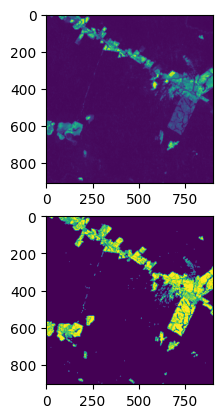

In [181]:
## plot example
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2)
ax[0].imshow(all_distances[0])
ax[1].imshow(all_alerts[0])

# FITTING MULTIPLE LEVELS CLASSIFICATION

In [182]:
## FITTING NONBINARY CLASSIFICATION

print(f'Total training data shape:{np.concatenate([i.flatten() for i in all_distances]).shape}')
print(f'Total GT shape:{np.concatenate([i.flatten() for i in all_alerts]).shape}')

normalized_X = np.concatenate([i.flatten() for i in all_distances])
normalized_Y = np.concatenate([i.flatten() for i in all_alerts])

'''minval, maxval = -100, 100
X = np.log(normalized_X/(1-normalized_X)).clip(minval, maxval)
y = np.log(normalized_Y/(1-normalized_Y)).clip(minval,maxval)'''

from scipy.optimize import curve_fit

def sigmoid_burned(x, w, b):
    return 4 / (1 + np.exp(-(w * x + b)))

popt, pcov = curve_fit(sigmoid_burned, normalized_X, 4*normalized_Y, p0=[0, -5])
wopt_nonbinary, bopt_nonbinary = popt

print(f"Optimal fitted params: w = {wopt_nonbinary:.4f}, b = {bopt_nonbinary:.4f}")

Total training data shape:(4892426,)
Total GT shape:(4892426,)
Optimal fitted params: w = 10.4532, b = -3.2787


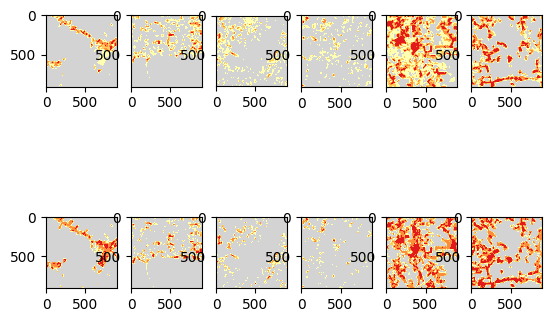

In [183]:
## TEST IT ON SOME IMAGES
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

cmap = mcolors.ListedColormap(["#d3d3d3", "#ffffb2", "#fecc5c", "#fd8d3c", "#e31a1c"])
norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], cmap.N)

index_to_test = -1
fig, ax = plt.subplots(ncols=len(all_distances), nrows=2)

for i in range(len(all_distances)):
    ax[0,i].imshow(sigmoid_burned(all_distances[i], wopt_nonbinary, bopt_nonbinary), cmap=cmap, norm=norm)
    ax[1,i].imshow(4*all_alerts[i], cmap=cmap, norm=norm)
plt.show()

# FITTING BINARY CLASSIFICATION

In [184]:
## FITTING BINARY CLASSIFICATION
binary_Y = np.where(normalized_Y==0, normalized_Y, 1)

def sigmoid_burned_binary(x, w, b):
    return 1 / (1 + np.exp(-(w * x + b)))

popt, pcov = curve_fit(sigmoid_burned_binary, normalized_X, binary_Y, p0=[0, -5])
wopt_binary, bopt_binary = popt

print(f"Optimal fitted params: w = {wopt_binary:.4f}, b = {bopt_binary:.4f}")

Optimal fitted params: w = 14.3453, b = -3.5202


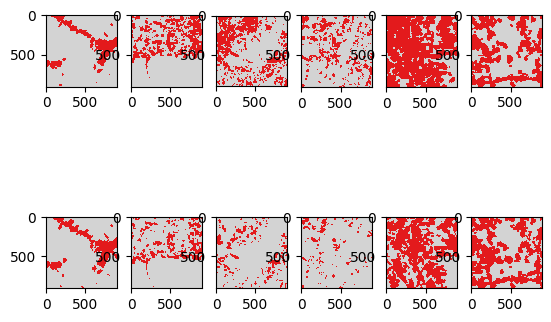

In [185]:
binary_cmap = mcolors.ListedColormap(["#d3d3d3", "#e31a1c"])
binary_norm = mcolors.BoundaryNorm([-0.5, 0.5, 1.5], binary_cmap.N)

index_to_test = 2
fig, ax = plt.subplots(ncols=len(all_distances), nrows=2)

for i in range(len(all_distances)):
    ax[0,i].imshow(sigmoid_burned(all_distances[i], wopt_binary, bopt_binary), cmap=binary_cmap, norm=binary_norm)
    ax[1,i].imshow(4*all_alerts[i], cmap=binary_cmap, norm=binary_norm)
plt.show()

# TESTING ON VALIDATION

In [186]:
validation_distances, validation_alerts = prepare_for_logistic(VALIDATION_IDS)

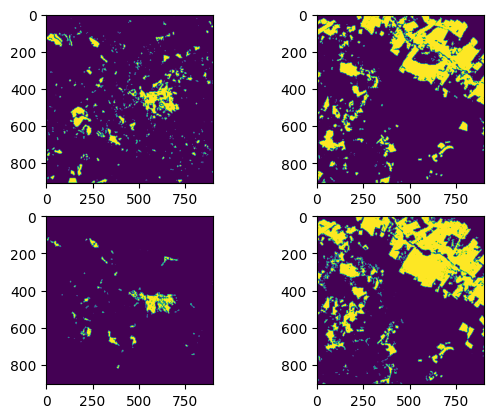

In [187]:
fig, ax = plt.subplots(nrows=2, ncols=len(validation_alerts))

p = .8
for i in range(len(validation_alerts)):
    predictions = sigmoid_burned(validation_distances[i], wopt_nonbinary, bopt_binary)
    ax[0,i].imshow((predictions>p).astype(int))
    ax[1,i].imshow((validation_alerts[i]>0).astype(int))

In [108]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

def compute_validation_metrics(
        p,
        validation_alerts,
        validation_distances
):
    all_y_true = []
    all_y_pred = []

    for dist, alert in zip(validation_distances, validation_alerts):
        preds_continuous = sigmoid_burned(dist, wopt_nonbinary, bopt_nonbinary)
        binary_preds = (preds_continuous > p).astype(int)
        binary_gt = (alert > 0).astype(int)
        
        all_y_true.append(binary_gt.flatten())
        all_y_pred.append(binary_preds.flatten())

    y_true = np.concatenate(all_y_true)
    y_pred = np.concatenate(all_y_pred)

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # IoU (Jaccard Index)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    iou = tp / (tp + fp + fn + 1e-8)

    metrics = {
        "threshold": p,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "confusion_matrix": {"tn": tn, "fp": fp, "fn": fn, "tp": tp}
    }

    return metrics

In [119]:
# METRICS CALCULATION
thresholds = np.linspace(.5,1,10)
best_p = 0
best_iou = 0

print(f"{'p':<10} | {'F1':<10} | {'IoU':<10} | {'Recall':<10}")
print("-" * 50)

for p in thresholds:
    m = compute_validation_metrics(p, validation_alerts, validation_distances)
    print(f"{p:<10.2f} | {m['f1_score']:<10.4f} | {m['iou']:<10.4f} | {m['recall']:<10.4f}")
    
    if m['iou'] > best_iou:
        best_iou = m['iou']
        best_p = p

print(f"\nSoglia ottimale p: {best_p}")

p          | F1         | IoU        | Recall    
--------------------------------------------------
0.50       | 0.6515     | 0.4831     | 0.8509    
0.56       | 0.6828     | 0.5183     | 0.8297    
0.61       | 0.7018     | 0.5406     | 0.8104    
0.67       | 0.7150     | 0.5565     | 0.7931    
0.72       | 0.7226     | 0.5656     | 0.7756    
0.78       | 0.7262     | 0.5702     | 0.7589    
0.83       | 0.7270     | 0.5711     | 0.7429    
0.89       | 0.7266     | 0.5705     | 0.7286    
0.94       | 0.7256     | 0.5693     | 0.7159    
1.00       | 0.7236     | 0.5669     | 0.7035    

Soglia ottimale p: 0.8333333333333333


In [127]:
optimal_p = 0.8333333333333333

In [149]:
def extract_test_names():
    '''extract names for all the specific geographic areas that we have'''
    items = set()
    for id in os.scandir(Path('data/makeathon-challenge/aef-embeddings/test')):
        items.add(id.name[:9])
    return tuple(items)
##

PATH_TO_TEST_EMBEDDINGS = Path('data/makeathon-challenge/aef-embeddings/test')

def extract_test_embeddings(ids):
    all_distances = []
    for id in ids:
        aef_embeddings = []   # evolution of the embeddings
        for year in YEARS:   
            with rasterio.open(PATH_TO_TEST_EMBEDDINGS / f'{id}_{year}.tiff') as src:
                embedding_array = []
                for i in range(64):
                    embedding_array.append(src.read(i+1))
                 ##
            ##
            aef_embeddings.append(np.stack(embedding_array))
        aef_embeddings = np.stack(aef_embeddings)

        cosine_distances = []
        for i in range(len(aef_embeddings)-1):
            tens1 = aef_embeddings[i]
            tens2 = aef_embeddings[i+1]
            cos_dist = handcraft_cosine(tens1, tens2)
            mask = np.isfinite(cos_dist)
            cosine_distances.append(np.where(mask, cos_dist, 0))
        ##
        cosine_distances = np.max(np.stack(cosine_distances), axis=0) # variations

        all_distances.append(normalize(cosine_distances))    

    return all_distances

TEST_IDS = extract_test_names()
test_distances = extract_test_embeddings(TEST_IDS)

In [152]:
test_distances[0].shape

(1006, 1002)

In [153]:
len(test_distances)

5

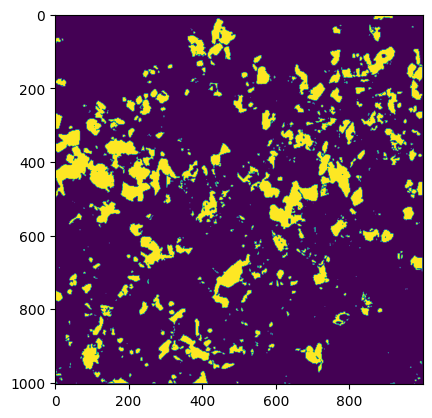

In [160]:
fig, ax = plt.subplots()

index = 2
probs = sigmoid_burned(test_distances[index], wopt_nonbinary, bopt_nonbinary)
preds = (probs > best_p).astype(int)
ax.imshow(preds)
plt.show()

## DEFINITIVE PREDICTIONS

In [161]:
predictions = [(sigmoid_burned(i, wopt_nonbinary, bopt_nonbinary) > optimal_p).astype(int) for i in test_distances]

In [172]:
import tempfile
import geopandas as gpd
from submission_utils import raster_to_geojson
OUTPUT_FOLDER = Path('output')

for id, embed in zip(TEST_IDS, predictions):
    with rasterio.open(PATH_TO_TEST_EMBEDDINGS / f'{id}_2020.tiff') as src:
        meta = src.meta.copy()
        transform = src.transform
        crs = src.crs

    meta.update(dtype="uint8", nodata=0, count=1)

    with tempfile.NamedTemporaryFile(suffix=".tif", delete=False) as tmp:
            tmp_path = tmp.name

    with rasterio.open(tmp_path, "w", **meta) as dst:
            print(tmp_path)
            dst.write(embed.astype(np.uint8), 1)


    Path(OUTPUT_FOLDER).mkdir(parents=True, exist_ok=True)
    geojson = raster_to_geojson(tmp_path, output_path=OUTPUT_FOLDER/f'{id}.geojson')
    Path(tmp_path).unlink()
    print(f"GeoJSON saved to: {OUTPUT_FOLDER}")

    gdf     = gpd.GeoDataFrame.from_features(geojson["features"], crs="EPSG:4326")
    gdf_utm = gdf.to_crs(gdf.estimate_utm_crs())
    gdf_utm["area_ha"] = gdf_utm.area / 10_000

    print(f"\nDeforestation statistics — tile {id}")
    print(f"  Number of polygons : {len(gdf_utm)}")
    print(f"  Total area         : {gdf_utm['area_ha'].sum():.2f} ha")
    print(f"  Min polygon size   : {gdf_utm['area_ha'].min():.4f} ha")
    print(f"  Max polygon size   : {gdf_utm['area_ha'].max():.2f} ha")
    print(f"  Avg polygon size   : {gdf_utm['area_ha'].mean():.4f} ha")

##

/var/folders/k2/vd48dhcn6y39dyvd_zk_77ym0000gn/T/tmpa72mqaem.tif
GeoJSON saved to: output

Deforestation statistics — tile 33NTE_5_1
  Number of polygons : 257
  Total area         : 630.61 ha
  Min polygon size   : 0.5100 ha
  Max polygon size   : 49.50 ha
  Avg polygon size   : 2.4537 ha
/var/folders/k2/vd48dhcn6y39dyvd_zk_77ym0000gn/T/tmpdgmswp4s.tif
GeoJSON saved to: output

Deforestation statistics — tile 48PWA_0_6
  Number of polygons : 662
  Total area         : 1536.00 ha
  Min polygon size   : 0.5001 ha
  Max polygon size   : 48.47 ha
  Avg polygon size   : 2.3202 ha
/var/folders/k2/vd48dhcn6y39dyvd_zk_77ym0000gn/T/tmpirveujb6.tif
GeoJSON saved to: output

Deforestation statistics — tile 18NYH_2_1
  Number of polygons : 248
  Total area         : 1397.89 ha
  Min polygon size   : 0.5000 ha
  Max polygon size   : 116.99 ha
  Avg polygon size   : 5.6367 ha
/var/folders/k2/vd48dhcn6y39dyvd_zk_77ym0000gn/T/tmpcco9dmn7.tif
GeoJSON saved to: output

Deforestation statistics — tile 4

In [173]:
import json
from pathlib import Path

# Cartella dove hai salvato i 5 geojson singoli
GEOJSON_FOLDER = Path('output')
FINAL_SUBMISSION_PATH = Path('output/final_complete_submission.geojson')

combined_features = []

# Iteriamo sui file prodotti
for geojson_file in GEOJSON_FOLDER.glob('*.geojson'):
    with open(geojson_file, 'r') as f:
        data = json.load(f)
        # data["features"] è una lista di poligoni
        combined_features.extend(data["features"])
        print(f"Aggiunte {len(data['features'])} feature da {geojson_file.name}")

# Creiamo l'oggetto finale unico
final_geojson = {
    "type": "FeatureCollection",
    "features": combined_features
}

# Salvataggio del file unico per la consegna
with open(FINAL_SUBMISSION_PATH, 'w') as f:
    json.dump(final_geojson, f)

print(f"\n✅ File pronto per la consegna: {FINAL_SUBMISSION_PATH}")
print(f"Numero totale di poligoni nel file: {len(combined_features)}")

Aggiunte 14 feature da 18NVJ_1_6.geojson
Aggiunte 257 feature da 33NTE_5_1.geojson
Aggiunte 248 feature da 18NYH_2_1.geojson
Aggiunte 700 feature da 47QMA_6_2.geojson
Aggiunte 662 feature da 48PWA_0_6.geojson

✅ File pronto per la consegna: output/final_complete_submission.geojson
Numero totale di poligoni nel file: 1881


# **STORING EVALUATION AS TORCH.TENSORS**
In this (last) section we store the masked data (non binary) as tensors.

In [ ]:
all_ids = TRAINING_IDS + VALIDATION_IDS
all_masks = all_distances + validation_distances

assert len(all_ids) == len(all_masks)

non_binary_masks = {k: sigmoid_burned(i, wopt_nonbinary, bopt_nonbinary) for k, i in zip(all_ids, all_masks)}
binary_masks = {k: sigmoid_burned_binary(i, wopt_binary, bopt_nonbinary) for k,i in zip(all_ids, all_masks)}

In [ ]:
print([(np.max(i), np.min(i)) for i in non_binary_masks.values()])
print([(np.max(i), np.min(i)) for i in binary_masks.values()])

[(3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647), (3.9969389240331745, 0.14523562681596647)]
[(0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162), (0.9999843747697428, 0.03630890670399162)]


In [201]:
import pickle

with open('masks/binary_masks.pickle', 'wb') as f:
    pickle.dump(binary_masks, f)
with open('masks/non_binary_masks.pickle', 'wb') as f:
    pickle.dump(non_binary_masks, f)